Player performance NBA

In [1]:
pip install numpy

In [2]:
from google.colab import drive
# if you mount your drive somewhere else, change the path accordingly
drive.mount('/content/gdrive/')

Mounted at /content/gdrive/


Append the directory to your python path using sys

In [3]:
import sys
#My Drive, change if needed
prefix = '/content/gdrive/MyDrive/'
# modify "customized_path_to_your_homework" here to where you uploaded your homework
customized_path_to_your_homework = 'machineLearning/Assignment4'
sys_path = prefix + customized_path_to_your_homework
sys.path.append(sys_path)

In [4]:
import zipfile
zip_path = '/content/gdrive/MyDrive/machineLearning/project/archive.zip'
with zipfile.ZipFile(zip_path, 'r') as z:
  z.extractall('/content/data')

#Linear Regression

In [8]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

df_per_game = pd.read_csv('/content/data/Player Per Game.csv')
df_advanced = pd.read_csv('/content/data/Advanced.csv')

adv_cols = ['player', 'season', 'usg_percent', 'ows', 'dws', 'ws', 'obpm', 'dbpm', 'bpm', 'vorp', 'per']
df_advanced = df_advanced[adv_cols]

df = pd.merge(df_per_game, df_advanced, on=['player', 'season'], how='inner')
df = df.sort_values(['player', 'season'])

base_stats = ['age', 'mp_per_game', 'pts_per_game', 'ast_per_game', 'trb_per_game',
              'stl_per_game', 'blk_per_game', 'fg_percent']
advanced_stats = ['usg_percent', 'ows', 'dws', 'ws', 'obpm', 'dbpm', 'bpm', 'vorp', 'per']
stats_cols = base_stats + advanced_stats

for col in stats_cols:
    df[f'prev_{col}'] = df.groupby('player')[col].shift(1)


features = [f'prev_{col}' for col in stats_cols]
target_cols = ['pts_per_game', 'ast_per_game', 'trb_per_game']

data = df.dropna(subset=features + target_cols).copy()
X = data[features]


  Predicting: pts_per_game

K-Fold CV R² (Ridge, training set)
  Scores : [0.819 0.801 0.819 0.824 0.822]
  Mean   : 0.817  (+/- 0.016)

Error Rate Metrics  (MAPE excludes pts_per_game < 1.0)
  Ridge            MAPE:  30.19%   SMAPE:  28.26%
  Random Forest    MAPE:  31.24%   SMAPE:  28.75%
  XGBoost          MAPE:  30.51%   SMAPE:  28.26%

--- Overall Performance ---


,Metric,Ridge,Random Forest,XGBoost (weighted)
0,RMSE,2.4837,2.5325,2.5131
1,MAE,1.6480,1.6968,1.6642
2,R² Score,0.8149,0.8076,0.8105
3,Elite MAE (Star (20+)),3.0264,2.9310,2.3253



--- Ridge Coefficients ---


,Feature,Coefficient
2,prev_pts_per_game,5.163522
12,prev_obpm,0.862822
13,prev_dbpm,0.371416
10,prev_dws,0.285723
8,prev_usg_percent,0.143217
3,prev_ast_per_game,0.127831
9,prev_ows,0.114549
6,prev_blk_per_game,0.022649
4,prev_trb_per_game,-0.000723
5,prev_stl_per_game,-0.005126



--- Random Forest Feature Importance ---


,Feature,Importance
2,prev_pts_per_game,0.820833
8,prev_usg_percent,0.016845
0,prev_age,0.014563
7,prev_fg_percent,0.013601
16,prev_per,0.012626
1,prev_mp_per_game,0.012405
13,prev_dbpm,0.011998
12,prev_obpm,0.011562
4,prev_trb_per_game,0.011433
3,prev_ast_per_game,0.010770



--- XGBoost Feature Importance ---


,Feature,Importance
2,prev_pts_per_game,0.611148
1,prev_mp_per_game,0.190858
15,prev_vorp,0.053257
8,prev_usg_percent,0.049927
12,prev_obpm,0.023150
16,prev_per,0.013260
0,prev_age,0.009231
3,prev_ast_per_game,0.008545
11,prev_ws,0.008197
4,prev_trb_per_game,0.004722


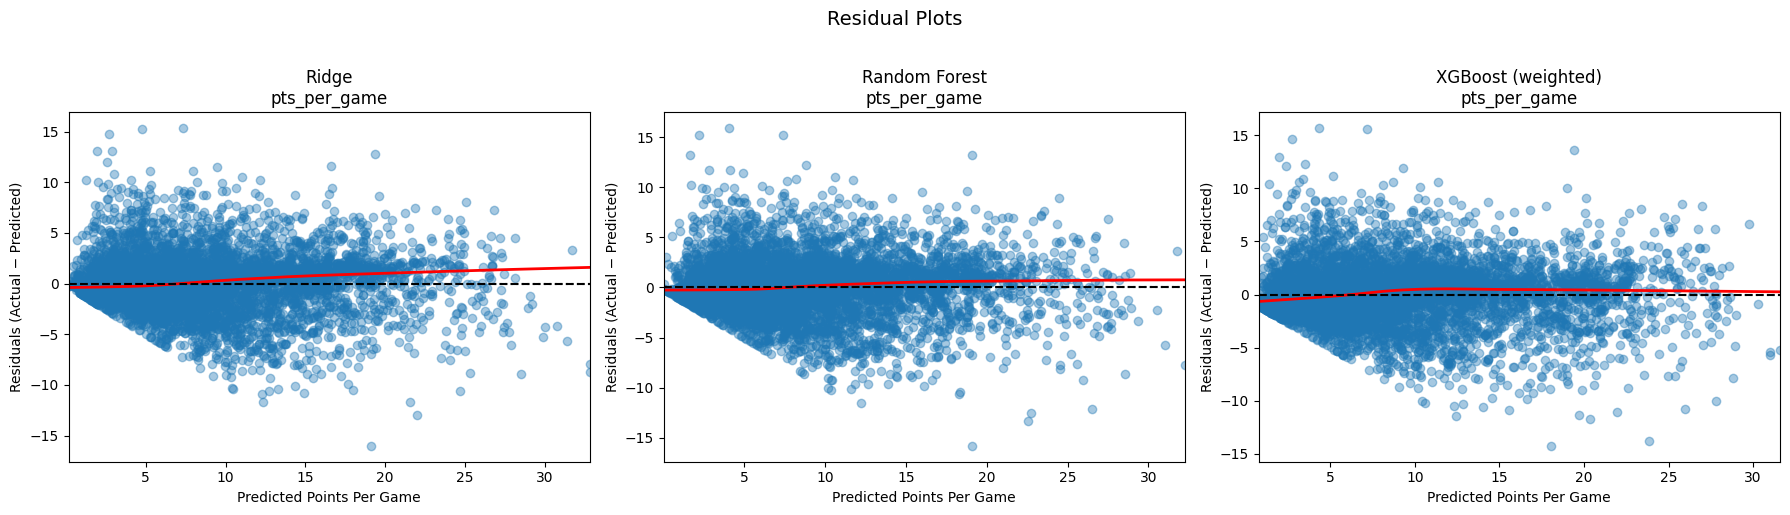

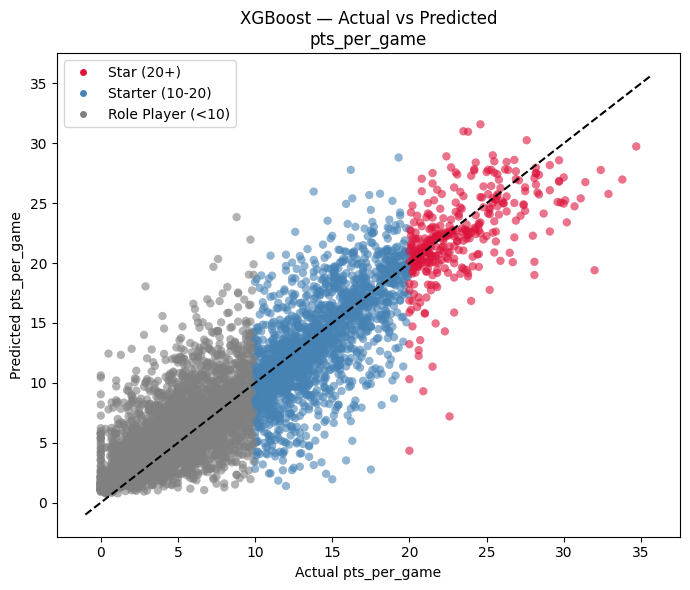


--- Performance by Player Tier ---


,Ridge_MAE,RF_MAE,XGB_MAE,Count
Bucket,,,,
Star (20+),3.0264,2.9310,2.3253,346
Starter (10-20),2.1161,2.1588,2.2465,1927
Role Player (<10),1.3897,1.4501,1.4112,5340



--- Top 10 Worst XGBoost Misses (Star (20+)) ---


,Actual,Predicted,Error
130,20.0,4.334000,15.666
196,22.6,7.203000,15.397
270,32.0,19.406000,12.594
213,20.9,9.300000,11.600
219,21.5,11.355000,10.145
86,20.0,10.306000,9.694
326,28.1,19.007999,9.092
171,20.6,12.254000,8.346
167,22.3,14.301000,7.999
161,28.1,20.112000,7.988



  Predicting: ast_per_game

K-Fold CV R² (Ridge, training set)
  Scores : [0.85  0.817 0.839 0.84  0.848]
  Mean   : 0.839  (+/- 0.023)

Error Rate Metrics  (MAPE excludes ast_per_game < 0.5)
  Ridge            MAPE:  26.12%   SMAPE:  35.41%
  Random Forest    MAPE:  27.90%   SMAPE:  35.95%
  XGBoost          MAPE:  27.24%   SMAPE:  35.19%

--- Overall Performance ---


...

,Feature,Coefficient
3,prev_ast_per_game,1.581307
12,prev_obpm,0.314634
13,prev_dbpm,0.139814
10,prev_dws,0.129542
9,prev_ows,0.113422
2,prev_pts_per_game,0.075150
5,prev_stl_per_game,0.053780
8,prev_usg_percent,0.024935
15,prev_vorp,-0.000019
7,prev_fg_percent,-0.012597



--- Random Forest Feature Importance ---


,Feature,Importance
3,prev_ast_per_game,0.840054
8,prev_usg_percent,0.013835
1,prev_mp_per_game,0.013074
4,prev_trb_per_game,0.012346
13,prev_dbpm,0.011567
7,prev_fg_percent,0.011533
0,prev_age,0.011388
16,prev_per,0.010879
2,prev_pts_per_game,0.010468
12,prev_obpm,0.009340



--- XGBoost Feature Importance ---


,Feature,Importance
3,prev_ast_per_game,0.463415
5,prev_stl_per_game,0.195612
12,prev_obpm,0.088578
1,prev_mp_per_game,0.060475
6,prev_blk_per_game,0.044631
14,prev_bpm,0.028108
4,prev_trb_per_game,0.024084
16,prev_per,0.021165
15,prev_vorp,0.014899
0,prev_age,0.010100


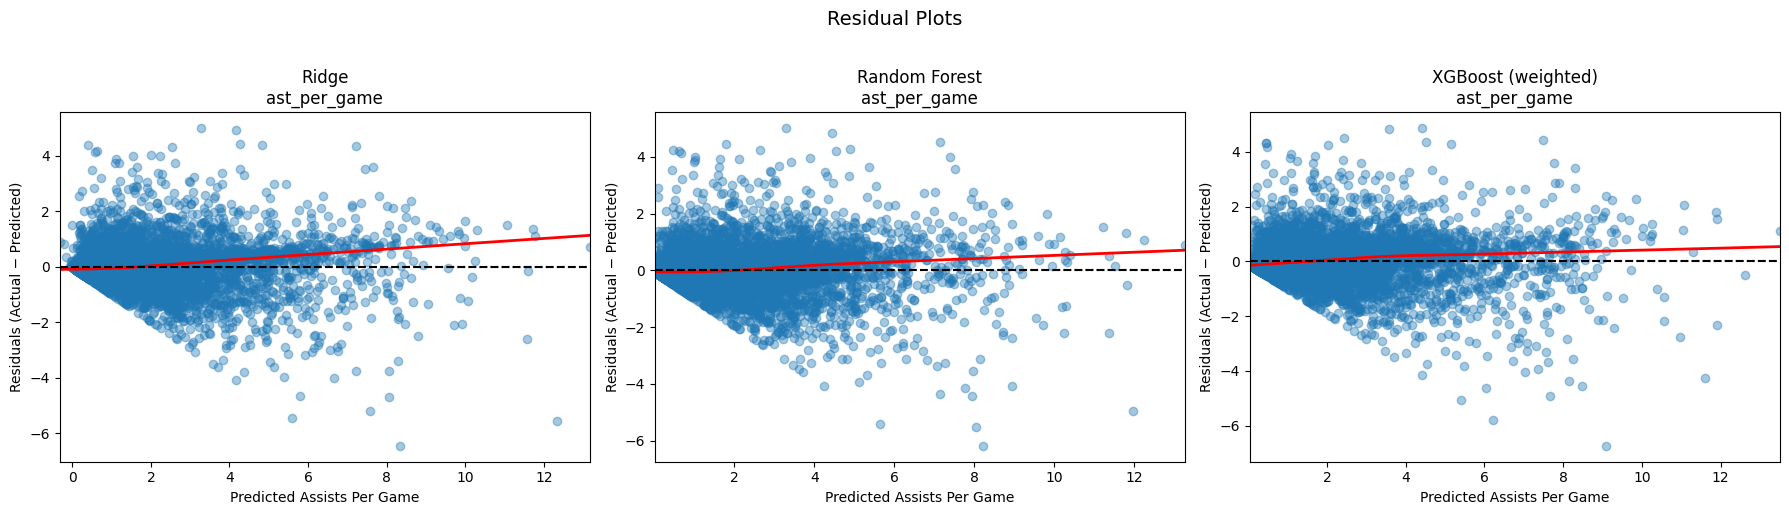

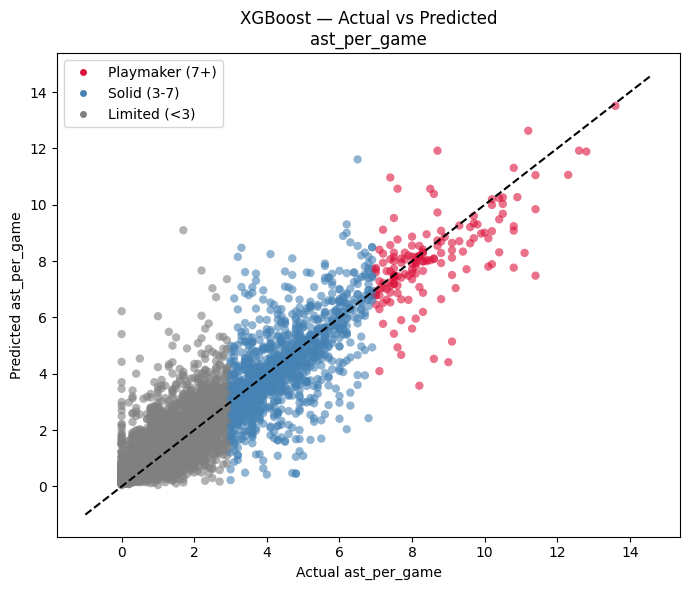


--- Performance by Player Tier ---


,Ridge_MAE,RF_MAE,XGB_MAE,Count
Bucket,,,,
Playmaker (7+),1.1497,1.1485,0.9303,154
Solid (3-7),0.7340,0.7807,0.7845,1301
Limited (<3),0.3421,0.3629,0.3576,6158



--- Top 10 Worst XGBoost Misses (Playmaker (7+)) ---


,Actual,Predicted,Error
86,8.2,3.575,4.625
95,9.0,4.411,4.589
70,8.6,4.527,4.073
57,9.1,5.143,3.957
115,11.4,7.481,3.919
35,7.4,10.965,3.565
24,8.7,11.918,3.218
73,10.8,7.766,3.034
4,7.7,4.669,3.031
34,7.1,4.091,3.009



  Predicting: trb_per_game

K-Fold CV R² (Ridge, training set)
  Scores : [0.805 0.816 0.808 0.808 0.819]
  Mean   : 0.811  (+/- 0.011)

Error Rate Metrics  (MAPE excludes trb_per_game < 0.5)
  Ridge            MAPE:  26.36%   SMAPE:  26.24%
  Random Forest    MAPE:  27.66%   SMAPE:  26.96%
  XGBoost          MAPE:  27.66%   SMAPE:  26.61%

--- Overall Performance ---


...

,Feature,Coefficient
4,prev_trb_per_game,2.145098
12,prev_obpm,0.138190
2,prev_pts_per_game,0.099212
10,prev_dws,0.093429
13,prev_dbpm,0.070143
6,prev_blk_per_game,0.070018
16,prev_per,0.059759
11,prev_ws,0.055406
8,prev_usg_percent,0.028812
5,prev_stl_per_game,0.002789



--- Random Forest Feature Importance ---


,Feature,Importance
4,prev_trb_per_game,0.813218
1,prev_mp_per_game,0.016205
8,prev_usg_percent,0.015455
7,prev_fg_percent,0.014609
16,prev_per,0.014086
13,prev_dbpm,0.014065
0,prev_age,0.013199
2,prev_pts_per_game,0.011528
10,prev_dws,0.011298
14,prev_bpm,0.010935



--- XGBoost Feature Importance ---


,Feature,Importance
4,prev_trb_per_game,0.475465
6,prev_blk_per_game,0.218387
10,prev_dws,0.072481
1,prev_mp_per_game,0.062697
16,prev_per,0.053612
7,prev_fg_percent,0.020123
2,prev_pts_per_game,0.012996
11,prev_ws,0.012970
3,prev_ast_per_game,0.012235
14,prev_bpm,0.009656


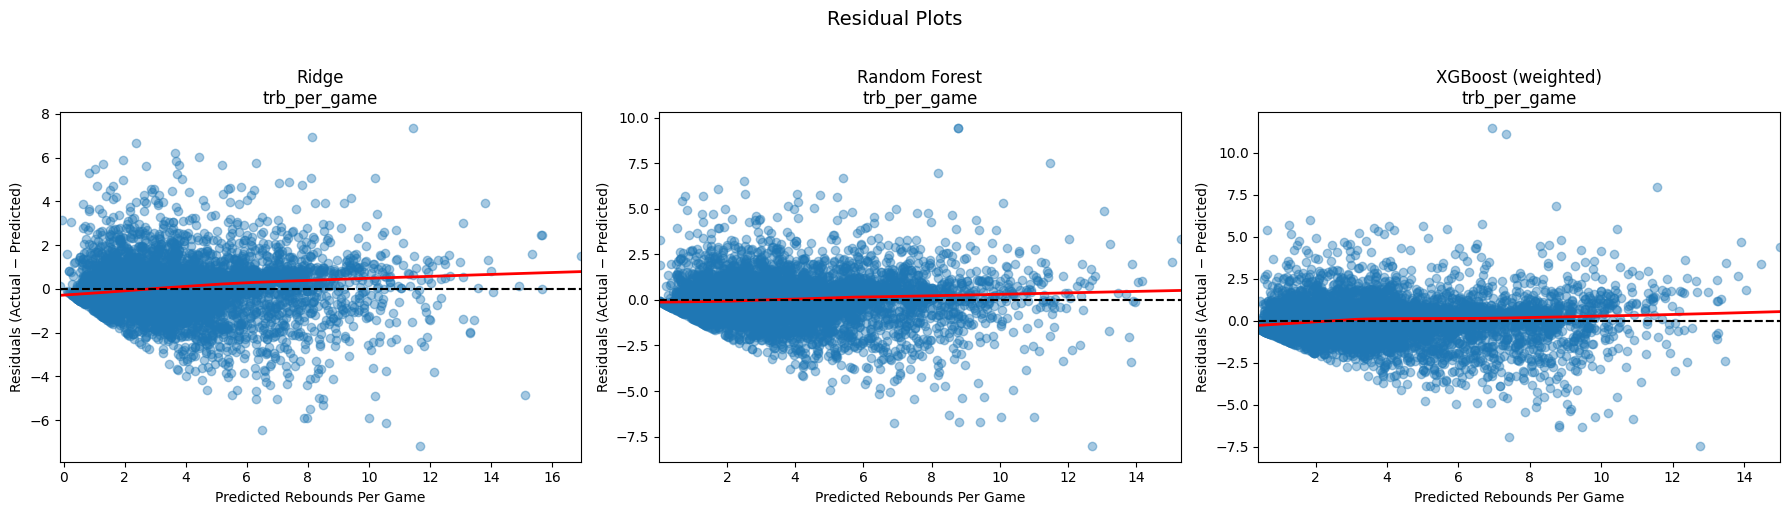

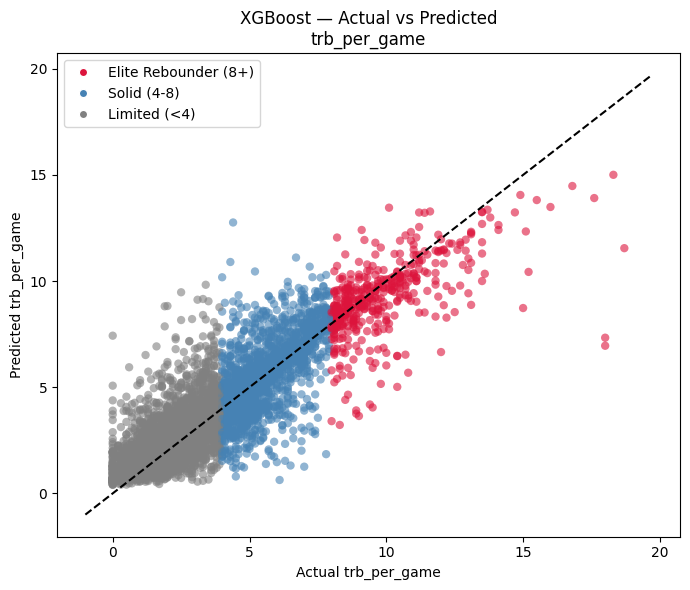


--- Performance by Player Tier ---


,Ridge_MAE,RF_MAE,XGB_MAE,Count
Bucket,,,,
Elite Rebounder (8+),1.4189,1.4188,1.1990,437
Solid (4-8),0.8389,0.8670,0.9127,1913
Limited (<4),0.5413,0.5768,0.5793,5263



--- Top 10 Worst XGBoost Misses (Elite Rebounder (8+)) ---


,Actual,Predicted,Error
301,18.0,6.953,11.047
180,18.0,7.332,10.668
99,18.7,11.549,7.151
385,15.0,8.729,6.271
403,9.5,4.045,5.455
179,10.4,5.015,5.385
262,9.0,3.645,5.355
245,12.0,6.656,5.344
309,9.4,4.187,5.213
388,8.9,3.755,5.145


In [13]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# ── Config ────────────────────────────────────────────────────────────────────
ELITE_WEIGHT = 5.0
BASE_WEIGHT  = 1.0

STAT_CONFIG = {
    'pts_per_game': {
        'thresholds': (20, 10),
        'labels':     ('Star (20+)', 'Starter (10-20)', 'Role Player (<10)'),
        'xlabel':     'Predicted Points Per Game',
        'mape_min':   1.0,
    },
    'ast_per_game': {
        'thresholds': (7, 3),
        'labels':     ('Playmaker (7+)', 'Solid (3-7)', 'Limited (<3)'),
        'xlabel':     'Predicted Assists Per Game',
        'mape_min':   0.5,
    },
    'trb_per_game': {
        'thresholds': (8, 4),
        'labels':     ('Elite Rebounder (8+)', 'Solid (4-8)', 'Limited (<4)'),
        'xlabel':     'Predicted Rebounds Per Game',
        'mape_min':   0.5,
    },
}

# ── Helpers ───────────────────────────────────────────────────────────────────
def get_sample_weights(y, high_threshold):
    return np.where(y >= high_threshold, ELITE_WEIGHT, BASE_WEIGHT)

def smape(actual, predicted):
    denom = (np.abs(actual) + np.abs(predicted))
    mask  = denom > 0
    return np.mean(2 * np.abs(predicted[mask] - actual[mask]) / denom[mask]) * 100

def elite_mae(y_true, y_pred, threshold):
    mask = y_true >= threshold
    if mask.sum() == 0:
        return np.nan
    return mean_absolute_error(y_true[mask], y_pred[mask])

# ── Main evaluation ───────────────────────────────────────────────────────────
def evaluate_predictions_for_stat(target_stat):
    print(f"\n{'='*60}")
    print(f"  Predicting: {target_stat}")
    print(f"{'='*60}")

    cfg        = STAT_CONFIG[target_stat]
    high, mid  = cfg['thresholds']
    label_high, label_mid, label_low = cfg['labels']

    y_stat = data[target_stat]

    # ── Train / test split (raw, unscaled) ────────────────────────────────────
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y_stat, test_size=0.2, random_state=42
    )

    # ── Ridge (pipeline handles scaling per CV fold) ──────────────────────────
    ridge_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('ridge',  Ridge(alpha=1.0))
    ])
    ridge_pipeline.fit(X_tr, y_tr)
    r_pred = ridge_pipeline.predict(X_te)

    # ── Random Forest (pipeline for consistent scaling) ───────────────────────
    rf_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('rf',     RandomForestRegressor(n_estimators=50, random_state=42))
    ])
    rf_pipeline.fit(X_tr, y_tr)
    f_pred = rf_pipeline.predict(X_te)

    # ── XGBoost with elite sample weighting ───────────────────────────────────
    scaler_xgb   = StandardScaler()
    X_tr_sc      = scaler_xgb.fit_transform(X_tr)
    X_te_sc      = scaler_xgb.transform(X_te)
    train_weights = get_sample_weights(y_tr.values, high)

    xgb_model = XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbosity=0,
    )
    xgb_model.fit(X_tr_sc, y_tr, sample_weight=train_weights)
    x_pred = xgb_model.predict(X_te_sc)

    # ── K-Fold CV on training data (Ridge pipeline) ───────────────────────────
    kf        = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(ridge_pipeline, X_tr, y_tr, cv=kf, scoring='r2')
    print(f"\nK-Fold CV R² (Ridge, training set)")
    print(f"  Scores : {np.round(cv_scores, 3)}")
    print(f"  Mean   : {cv_scores.mean():.3f}  (+/- {cv_scores.std() * 2:.3f})")

    # ── MAPE / SMAPE ──────────────────────────────────────────────────────────
    mape_min = cfg['mape_min']
    mask     = y_te >= mape_min

    print(f"\nError Rate Metrics  (MAPE excludes {target_stat} < {mape_min})")
    for name, preds in [('Ridge', r_pred), ('Random Forest', f_pred), ('XGBoost', x_pred)]:
        mape  = mean_absolute_percentage_error(y_te[mask], preds[mask]) * 100
        smap  = smape(y_te.values, preds)
        print(f"  {name:<15}  MAPE: {mape:6.2f}%   SMAPE: {smap:6.2f}%")

    # ── Overall performance table ─────────────────────────────────────────────
    y_te_vals = y_te.values
    res = pd.DataFrame({
        'Metric': ['RMSE', 'MAE', 'R² Score', f'Elite MAE ({label_high})'],
        'Ridge': [
            np.sqrt(mean_squared_error(y_te_vals, r_pred)),
            mean_absolute_error(y_te_vals, r_pred),
            r2_score(y_te_vals, r_pred),
            elite_mae(y_te_vals, r_pred, high),
        ],
        'Random Forest': [
            np.sqrt(mean_squared_error(y_te_vals, f_pred)),
            mean_absolute_error(y_te_vals, f_pred),
            r2_score(y_te_vals, f_pred),
            elite_mae(y_te_vals, f_pred, high),
        ],
        'XGBoost (weighted)': [
            np.sqrt(mean_squared_error(y_te_vals, x_pred)),
            mean_absolute_error(y_te_vals, x_pred),
            r2_score(y_te_vals, x_pred),
            elite_mae(y_te_vals, x_pred, high),
        ],
    }).round(4)
    print("\n--- Overall Performance ---")
    display(res)

    # ── Feature importance ────────────────────────────────────────────────────
    ridge_coefs = pd.DataFrame({
        'Feature':     features,
        'Coefficient': ridge_pipeline.named_steps['ridge'].coef_
    }).sort_values('Coefficient', ascending=False)
    print("\n--- Ridge Coefficients ---")
    display(ridge_coefs)

    rf_imp = pd.DataFrame({
        'Feature':    features,
        'Importance': rf_pipeline.named_steps['rf'].feature_importances_
    }).sort_values('Importance', ascending=False)
    print("\n--- Random Forest Feature Importance ---")
    display(rf_imp)

    xgb_imp = pd.DataFrame({
        'Feature':    features,
        'Importance': xgb_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    print("\n--- XGBoost Feature Importance ---")
    display(xgb_imp)

    # ── Residual plots (3 models side by side) ────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, preds, title in zip(
        axes,
        [r_pred, f_pred, x_pred],
        ['Ridge', 'Random Forest', 'XGBoost (weighted)']
    ):
        sns.residplot(
            x=preds, y=y_te_vals, lowess=True,
            scatter_kws={'alpha': 0.4},
            line_kws={'color': 'red', 'lw': 2},
            ax=ax
        )
        ax.set_title(f'{title}\n{target_stat}')
        ax.set_xlabel(cfg['xlabel'])
        ax.set_ylabel('Residuals (Actual − Predicted)')
        ax.axhline(y=0, color='black', linestyle='--')
    plt.suptitle('Residual Plots', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

    # ── Actual vs Predicted scatter (XGBoost only) ────────────────────────────
    plt.figure(figsize=(7, 6))
    colors = np.where(y_te_vals >= high, 'crimson',
             np.where(y_te_vals >= mid,  'steelblue', 'grey'))
    plt.scatter(y_te_vals, x_pred, c=colors, alpha=0.6, edgecolors='none')
    lims = [min(y_te_vals.min(), x_pred.min()) - 1,
            max(y_te_vals.max(), x_pred.max()) + 1]
    plt.plot(lims, lims, 'k--', lw=1.5, label='Perfect prediction')
    from matplotlib.lines import Line2D
    legend_els = [
        Line2D([0],[0], marker='o', color='w', markerfacecolor='crimson',   label=label_high),
        Line2D([0],[0], marker='o', color='w', markerfacecolor='steelblue', label=label_mid),
        Line2D([0],[0], marker='o', color='w', markerfacecolor='grey',      label=label_low),
    ]
    plt.legend(handles=legend_els)
    plt.xlabel(f'Actual {target_stat}')
    plt.ylabel(f'Predicted {target_stat}')
    plt.title(f'XGBoost — Actual vs Predicted\n{target_stat}')
    plt.tight_layout()
    plt.show()

    # ── Bucket / tier breakdown ───────────────────────────────────────────────
    def get_bucket(val):
        if val >= high:  return label_high
        elif val >= mid: return label_mid
        else:            return label_low

    results_df = pd.DataFrame({
        'Actual':      y_te_vals,
        'Ridge_Err':   np.abs(y_te_vals - r_pred),
        'RF_Err':      np.abs(y_te_vals - f_pred),
        'XGB_Err':     np.abs(y_te_vals - x_pred),
    })
    results_df['Bucket'] = results_df['Actual'].apply(get_bucket)

    bucket_analysis = results_df.groupby('Bucket').agg(
        Ridge_MAE =('Ridge_Err', 'mean'),
        RF_MAE    =('RF_Err',    'mean'),
        XGB_MAE   =('XGB_Err',   'mean'),
        Count     =('Actual',    'count')
    ).reindex([label_high, label_mid, label_low]).round(4)

    print("\n--- Performance by Player Tier ---")
    display(bucket_analysis)

    # ── Worst XGBoost misses in the elite tier ────────────────────────────────
    elite_mask = y_te_vals >= high
    if elite_mask.sum() > 0:
        elite_df = pd.DataFrame({
            'Actual':    y_te_vals[elite_mask],
            'Predicted': x_pred[elite_mask],
            'Error':     np.abs(y_te_vals[elite_mask] - x_pred[elite_mask])
        }).sort_values('Error', ascending=False).head(10).round(3)
        print(f"\n--- Top 10 Worst XGBoost Misses ({label_high}) ---")
        display(elite_df)


# ── Run ───────────────────────────────────────────────────────────────────────
for stat in ['pts_per_game', 'ast_per_game', 'trb_per_game']:
    evaluate_predictions_for_stat(stat)